# Lab 04: The Scaling Relation That Depends on How You Fit It

**ASTR 457, Fall 2026, posted Thu Sep 24, due Wed Sep 30 by Noon (fork → PR, as always)**

**Extra credit, +5 points on this lab:** if you attended Charlotte Ward's Sep 22 Astronomy Colloquium, turn in at least a page of notes including two questions you had, as a text file in your `submissions/<netid>/` folder, by Noon Tue Sep 29.

*Why this lab: every scaling relation you will ever use ($M_{\rm BH}$–$\sigma$, Tully–Fisher, the mass–metallicity relation, the SN Ia standardization) was fit by someone who chose a regression method, and the choice changes the published slope. Knowing when ordinary least squares lies, by how much, and what to do instead is how you read those papers, and how you referee them.*

Every one of you has your own dataset: `data/<your netid>.csv`, a sample of dwarf
galaxies hosting active galactic nuclei, selected by their optical variability in the
style of Ward et al. (2022, arXiv:2110.13098). Dwarf-galaxy AGN are one of the few
windows we have on black holes in the $10^5$–$10^7\,M_\odot$ range, where the seeds of
supermassive black holes hide. Columns:

- `logMstar`, `err_logMstar`: $x = \log_{10}(M_*/M_\odot)$, the host stellar mass from
  SED fitting, and its $1\sigma$ uncertainty (0.2–0.4 dex; dwarf-galaxy photometry is hard),
- `logMBH`, `err_logMBH`: $y = \log_{10}(M_{\rm BH}/M_\odot)$, the virial black-hole
  mass from broad-line spectroscopy, and its $1\sigma$ uncertainty.

The relation you are after is

$$y = \alpha\,(x - 9.5) + \beta + \text{intrinsic scatter } \sigma_{\rm int},$$

pivoted at $M_* = 10^{9.5} M_\odot$ so $\alpha$ and $\beta$ don't fight each other. **Both
variables have measurement error, and the relation has real astrophysical scatter on top.**
I know your true $\alpha$, $\beta$, and $\sigma_{\rm int}$. You don't, your classmates'
values are different from yours, and so are your sample sizes.

**How this is graded.** Not on whether your code runs, but on whether your answers are
*right* and your uncertainties are *honest*. Part of your grade comes from how close your
reported $\alpha$ and $\beta$ are to your truth **in units of your own reported
uncertainty**. Tiny error bars you can't back up lose points; padded ones lose points too.
Calibration is the skill. The floor under "padded": your reported $\sigma_\alpha$ may not
exceed **3× the curvature uncertainty of your own generative fit** from Part 2 (if your
Hessian turns out singular, quote a profile-likelihood width instead and say so). Bigger
than that is not caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The fit everyone does first (15%)

Load your sample and plot it with error bars **on both axes**. Then fit the relation the
way most papers still do: **ordinary least squares** on $y$ vs $(x - 9.5)$, every point
weighted equally, errors ignored. Build the design matrix and solve the normal equations
yourself (lecture machinery, or `np.polyfit` if you must, but know what it's doing). Report
$\hat\alpha \pm \sigma$ using the standard OLS variance estimate, $s^2 (A^{\mathsf T}A)^{-1}$
with $s^2 = \mathrm{RSS}/(N-2)$ (residual-scaled; the errors play no role yet, on purpose).

Then answer, in a few sentences: which of OLS's assumptions does *your* dataset violate?
For the slope specifically, which way does the bias from the $x$-errors pull, and what
controls its size? (We named it in lecture on Sep 24. The effect is *supposed*
to be there; understanding exactly why, on your own data, is the point of this lab.)

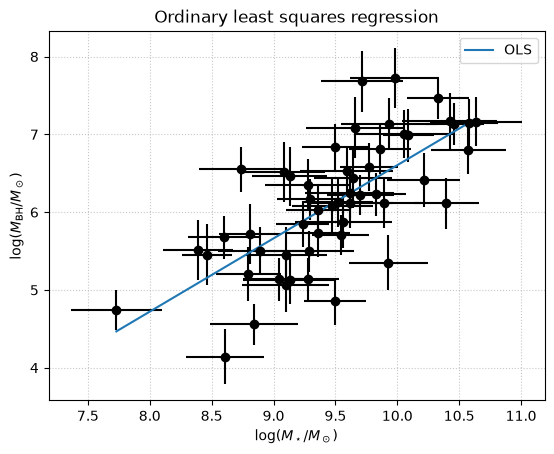

OLS fit values:
alpha = 0.941 +/- 0.132
beta = 6.134 +/- 0.081


In [28]:
# Part 1: your work here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def ols(A, y):
    """theta_hat, its covariance (residual-scaled) and the residuals, for design matrix A and data y."""
    AtA_inv = np.linalg.inv(A.T @ A)
    theta = AtA_inv @ A.T @ y
    resid = y - A @ theta
    s2 = resid @ resid / (len(y) - A.shape[1])
    return theta, s2 * AtA_inv, resid

datafile = f'./data/ahuwer2.csv'
data = pd.read_csv(datafile)
#print(data)
logMstar = data['logMstar'].values
err_logMstar = data['err_logMstar']
logMBH = data['logMBH'].values
err_logMBH = data['err_logMBH']

A = np.vstack([np.ones_like(logMstar), logMstar - 9.5]).T
theta, covTheta, resid = ols(A, logMBH)
sig_a = np.sqrt(covTheta[1,1])
sig_b = np.sqrt(covTheta[0,0])

plt.errorbar(logMstar, logMBH, err_logMBH, err_logMstar, 'ko')
plt.plot(logMstar, theta[0] + theta[1] * (logMstar - 9.5), label='OLS')
plt.xlabel('$\\log(M_\\star/M_\\odot)$')
plt.ylabel('$\\log(M_{\\rm BH}/M_\\odot)$')
plt.title('Ordinary least squares regression')
plt.grid(True, 'both', linestyle=':', alpha=0.7)
plt.legend()
plt.show()

print(f'OLS fit values:')
print(f'alpha = {theta[1]:.3f} +/- {sig_a:.3f}')
print(f'beta = {theta[0]:.3f} +/- {sig_b:.3f}')

**ANSWER (a few sentences):**

$\hat{\alpha}=0.941\pm0.132$

The main assumption of OLS that we're breaking with this dataset is that we have errors which can and will introduce bias into the OLS fit solution. Since we know this data will have x errors, we automatically know that the slope will be biased down on average. This downwards bias is controlled by the relative error, specifically the ratio of $\sigma_x$ to $\sigma_{pop}$. If $\sigma_{x}$ is small relative to $\sigma_{pop}$, then we expect the average ratio of OLS slope to the truth, given by $\sigma_{pop}^2/(\sigma_{pop}^2+\sigma_x^2)$ to be just under 1, and if $\sigma_{x}$ is relatively large compared to $\sigma_{pop}$ that expected ratio should be lower, i.e. more biased.

## Part 2: Estimators you can defend (40%)

Now fit the relation **three more ways** and compare:

1. **Weighted least squares** using the $y$-errors only:
   $\hat{\theta} = (A^{\mathsf T}\Sigma^{-1}A)^{-1}A^{\mathsf T}\Sigma^{-1}y$ with
   $\Sigma = \mathrm{diag}(\sigma_{y,i}^2)$, parameter covariance
   $(A^{\mathsf T}\Sigma^{-1}A)^{-1}$. Does weighting fix the Part 1 bias? Why or why not?

2. **Orthogonal distance regression** (`scipy.odr`, which warns that it is deprecated on
   import; that is fine in the course environment), which knows about the $x$-errors.
   Read what it minimizes before you run it. What does ODR assume about scatter
   *perpendicular to the relation*, and is that assumption true here?

3. **The generative model, honestly.** Write down where each data point comes from:
   the true stellar masses are drawn from the population,
   $x_i^{\rm true} \sim \mathcal{N}(\mu, \sigma_{\rm pop}^2)$; the relation plus intrinsic scatter
   makes the true BH mass; and your measurement errors corrupt both. Marginalizing over
   the (unobservable) true masses makes each observed pair $(x_i, y_i)$ a **bivariate
   Gaussian**:

   $$\begin{pmatrix} x_i \\ y_i \end{pmatrix} \sim \mathcal{N}\!\left[
   \begin{pmatrix} \mu \\ \alpha(\mu - 9.5) + \beta \end{pmatrix},\;
   \begin{pmatrix} \sigma_{\rm pop}^2 + \sigma_{x,i}^2 & \alpha\,\sigma_{\rm pop}^2 \\
   \alpha\,\sigma_{\rm pop}^2 & \alpha^2\sigma_{\rm pop}^2 + \sigma_{\rm int}^2 + \sigma_{y,i}^2 \end{pmatrix}
   \right]$$

   (Convince yourself of the three variance entries before you code; the off-diagonal
   covariance is what removes the attenuation bias. This is the Gaussian core of Kelly 2007, the paper behind
   every modern `linmix`-style fit.) Maximize the summed log-likelihood over all five
   parameters $(\alpha, \beta, \sigma_{\rm int}, \mu, \sigma_{\rm pop})$, and get uncertainties from
   the curvature of the log-likelihood at its peak (the observed information), and say so.

Make **one plot with all four fitted lines overplotted** on your data. They will not agree.
Explain, estimator by estimator, *why* each lands where it does, and which ingredient of the
data each one ignores.

Commit to a **final answer**: one $\alpha \pm \sigma$, $\beta \pm \sigma$, and
$\sigma_{\rm int} \pm \sigma$ you'd put in a paper, and justify the choice. Remember the
3× rule from the header.

WLS
  alpha = 0.943 +/- 0.068
  beta  = 6.098 +/- 0.043
  chi2 = 168.9 for 51 dof, reduced = 3.31
ODR
  alpha = 1.391 +/- 0.158   (unscaled: 0.130)
  beta  = 6.098 +/- 0.087
  res_var = 1.49
eigenvalues of Hessian: [ 30.18220079 109.2120519  117.91334041 208.58294553 267.83699902]
Generative model (errors from curvature of the log-likelihood at the peak)
  alpha      = 1.225 +/- 0.174
  beta       = 6.109 +/- 0.081
  sigma_int  = 0.333 +/- 0.103
  mu         = 9.502 +/- 0.085
  sigma_pop  = 0.543 +/- 0.068
  -lnL at peak = 95.07


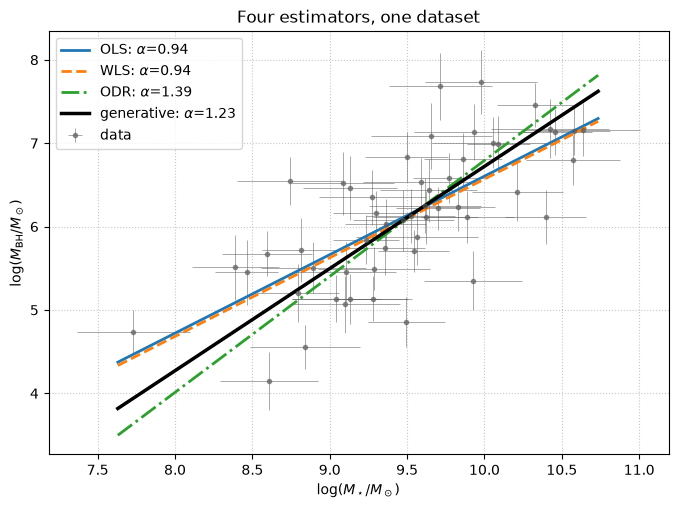

method          alpha   sig_a     beta   sig_b  (alpha - alpha_gen)/sig_gen
OLS             0.941   0.132    6.134   0.081  -1.63
WLS             0.943   0.068    6.098   0.043  -1.62
ODR             1.391   0.158    6.098   0.087  +0.95
Generative      1.225   0.174    6.109   0.081  +0.00


In [29]:
# Part 2: your work here
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
from scipy import odr

# plain arrays (err_* were pandas Series)
x, y = np.asarray(logMstar, float), np.asarray(logMBH, float)
sx, sy = np.asarray(err_logMstar, float), np.asarray(err_logMBH, float)
N = len(x)
xx = np.linspace(x.min() - 0.1, x.max() + 0.1, 100)

# ---------- 1. WLS, y-errors only ----------
def wls(A, y, sigma):
    W = 1.0 / sigma**2
    cov = np.linalg.inv(A.T @ (A * W[:, None]))
    return cov @ A.T @ (W * y), cov

th_w, cov_w = wls(A, y, sy)
chi2_w = np.sum(((y - A @ th_w) / sy)**2)
print("WLS")
print(f"  alpha = {th_w[1]:.3f} +/- {np.sqrt(cov_w[1,1]):.3f}")
print(f"  beta  = {th_w[0]:.3f} +/- {np.sqrt(cov_w[0,0]):.3f}")
print(f"  chi2 = {chi2_w:.1f} for {N-2} dof, reduced = {chi2_w/(N-2):.2f}")

# ---------- 2. ODR ----------
def line(B, xv):                 # B = [alpha, beta]
    return B[0] * (xv - 9.5) + B[1]

odr_data = odr.RealData(x, y, sx=sx, sy=sy)
odr_fit = odr.ODR(odr_data, odr.Model(line), beta0=[th_w[1], th_w[0]]).run()

a_odr, b_odr = odr_fit.beta
sa_odr, sb_odr = odr_fit.sd_beta                        # scaled by res_var
sa_odr_raw = np.sqrt(odr_fit.cov_beta[0, 0])            # NOT scaled by res_var
print("ODR")
print(f"  alpha = {a_odr:.3f} +/- {sa_odr:.3f}   (unscaled: {sa_odr_raw:.3f})")
print(f"  beta  = {b_odr:.3f} +/- {sb_odr:.3f}")
print(f"  res_var = {odr_fit.res_var:.2f}")

# ---------- 3. generative model ----------
# p = [alpha, beta, sig_int, mu, sig_pop]   (sigmas enter squared / via abs)
def nll(p, x=x, y=y, sx=sx, sy=sy):
    a, b, si, mu, sp = p
    si, sp = abs(si), abs(sp)
    Sxx = sp**2 + sx**2
    Sxy = a * sp**2
    Syy = a**2 * sp**2 + si**2 + sy**2
    det = Sxx * Syy - Sxy**2
    if np.any(det <= 0):
        return 1e25
    dx = x - mu
    dy = y - (a * (mu - 9.5) + b)
    q = (Syy * dx**2 - 2 * Sxy * dx * dy + Sxx * dy**2) / det
    return 0.5 * np.sum(q + np.log(det)) + len(x) * np.log(2 * np.pi)

def fit_gen(x=x, y=y, sx=sx, sy=sy, starts=None):
    f = lambda p: nll(p, x, y, sx, sy)
    sp0 = np.sqrt(max(np.var(x, ddof=1) - np.mean(sx**2), 0.05))
    if starts is None:
        starts = [[a0, np.mean(y), s0, np.mean(x), sp0]
                  for a0 in (0.5, 1.0, 1.5) for s0 in (0.1, 0.4)]
    best = None
    for p0 in starts:
        r = minimize(f, p0, method='Nelder-Mead',
                     options=dict(maxiter=20000, xatol=1e-9, fatol=1e-10))
        r = minimize(f, r.x, method='BFGS')
        if best is None or r.fun < best.fun:
            best = r
    best.x[2:3] = np.abs(best.x[2:3]); best.x[4] = abs(best.x[4])
    return best

def num_hess(f, p, rel=1e-3):
    p = np.asarray(p, float); n = len(p)
    h = rel * np.maximum(np.abs(p), 0.1)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            ei = np.zeros(n); ei[i] = h[i]
            ej = np.zeros(n); ej[j] = h[j]
            H[i, j] = H[j, i] = (f(p+ei+ej) - f(p+ei-ej)
                                 - f(p-ei+ej) + f(p-ei-ej)) / (4*h[i]*h[j])
    return H

res_g = fit_gen()
p_hat = res_g.x
H = num_hess(nll, p_hat)
print("eigenvalues of Hessian:", np.linalg.eigvalsh(H))   # all must be > 0

cov_g = np.linalg.inv(H)                 # observed information, inverted
sig_g = np.sqrt(np.diag(cov_g))
names = ['alpha', 'beta', 'sigma_int', 'mu', 'sigma_pop']
print("Generative model (errors from curvature of the log-likelihood at the peak)")
for n_, v, s in zip(names, p_hat, sig_g):
    print(f"  {n_:10s} = {v:.3f} +/- {s:.3f}")
print(f"  -lnL at peak = {res_g.fun:.2f}")

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.errorbar(x, y, yerr=sy, xerr=sx, fmt='o', color='0.35', ms=3,
            elinewidth=0.6, alpha=0.6, label='data')
ax.plot(xx, theta[0] + theta[1]*(xx - 9.5), lw=2, label=f'OLS: $\\alpha$={theta[1]:.2f}')
ax.plot(xx, th_w[0] + th_w[1]*(xx - 9.5), lw=2, ls='--', label=f'WLS: $\\alpha$={th_w[1]:.2f}')
ax.plot(xx, b_odr + a_odr*(xx - 9.5), lw=2, ls='-.', label=f'ODR: $\\alpha$={a_odr:.2f}')
ax.plot(xx, p_hat[1] + p_hat[0]*(xx - 9.5), 'k', lw=2.5, label=f'generative: $\\alpha$={p_hat[0]:.2f}')
ax.set_xlabel('$\\log(M_\\star/M_\\odot)$'); ax.set_ylabel('$\\log(M_{\\rm BH}/M_\\odot)$')
ax.set_title('Four estimators, one dataset')
ax.grid(True, ls=':', alpha=0.7); ax.legend(); plt.show()

rows = [('OLS', theta[1], sig_a, theta[0], sig_b),
        ('WLS', th_w[1], np.sqrt(cov_w[1,1]), th_w[0], np.sqrt(cov_w[0,0])),
        ('ODR', a_odr, sa_odr, b_odr, sb_odr),
        ('Generative', p_hat[0], sig_g[0], p_hat[1], sig_g[1])]
print(f"{'method':12s} {'alpha':>8s} {'sig_a':>7s} {'beta':>8s} {'sig_b':>7s}  (alpha - alpha_gen)/sig_gen")
for n_, a, sa, b, sb in rows:
    print(f"{n_:12s} {a:8.3f} {sa:7.3f} {b:8.3f} {sb:7.3f}  {(a - p_hat[0])/sig_g[0]:+.2f}")

**FINAL ANSWER:** $\alpha = $ ___ $\pm$ ___ , $\beta = $ ___ $\pm$ ___ , $\sigma_{\rm int} = $ ___ $\pm$ ___ dex

**Justification and uncertainty method (a short paragraph):**

*your answer goes here*

## Part 3: The verification plan, written first and then executed (35%)

**Before you run anything below, write the plan** (3a). A verification plan you invent
after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the generative recipe in
   Part 2 tells you exactly how) and confirm your fit recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot each estimator's bias and variance for $\alpha$. This is
   *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time, for all three reported parameters?
4. **Sensitivity**: what happens to $\hat\alpha$ if the catalog $x$-errors are wrong by
   ±50% (generate correctly, fit with the mis-stated errors)? If the true population isn't Gaussian (try drawing $x^{\rm true}$ from a uniform
   distribution with the same mean and variance instead)? If you had assumed $\sigma_{\rm int} = 0$?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

*your plan goes here*

In [30]:
# Part 3b: execute the plan here

**WHAT THE CHECKS FOUND:**

*your report goes here*

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true.

**AI-USE APPENDIX:**

*your answer goes here*